In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("Dyt-desktop.csv", sep=";")

In [4]:
data.head()

,Gender,Nativelang,Otherlang,Age,Clicks1,Hits1,Misses1,Score1,Accuracy1,Missrate1,...,Score31,Accuracy31,Missrate31,Clicks32,Hits32,Misses32,Score32,Accuracy32,Missrate32,Dyslexia
0,Male,No,Yes,7,10,10,0,10,1.0,0.0,...,0,0.000000,0.00,17,2,0,2,0.117647,0.000000,No
1,Female,Yes,Yes,13,12,12,0,12,1.0,0.0,...,4,0.114286,0.00,26,2,2,2,0.076923,0.076923,Yes
2,Female,No,Yes,7,6,6,0,6,1.0,0.0,...,4,0.114286,0.00,26,1,3,1,0.038462,0.115385,No
3,Female,No,Yes,7,0,0,0,0,0.0,0.0,...,0,0.000000,0.00,1,0,0,0,0.000000,0.000000,No
4,Female,No,Yes,8,4,4,0,4,1.0,0.0,...,1,25.000000,0.05,26,2,2,2,0.076923,0.076923,No


In [5]:
print(data.shape)

(3644, 197)


In [6]:
print(data["Dyslexia"].value_counts())

Dyslexia
No     3252
Yes     392
Name: count, dtype: int64


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3644 entries, 0 to 3643
Columns: 197 entries, Gender to Dyslexia
dtypes: float64(64), int64(129), str(4)
memory usage: 5.5 MB


In [8]:
missing_values = data.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [9]:
print("Total missing values:", data.isnull().sum().sum())

Total missing values: 0


In [10]:
print("Gender:")
print(data["Gender"].value_counts())

print("\nNativelang:")
print(data["Nativelang"].value_counts())

print("\nOtherlang:")
print(data["Otherlang"].value_counts())

print("\nDyslexia:")
print(data["Dyslexia"].value_counts())

Gender:
Gender
Male      1851
Female    1793
Name: count, dtype: int64

Nativelang:
Nativelang
No     2674
Yes     970
Name: count, dtype: int64

Otherlang:
Otherlang
Yes    2955
No      689
Name: count, dtype: int64

Dyslexia:
Dyslexia
No     3252
Yes     392
Name: count, dtype: int64


In [11]:
print(data.dtypes)

Gender            str
Nativelang        str
Otherlang         str
Age             int64
Clicks1         int64
               ...   
Misses32        int64
Score32         int64
Accuracy32    float64
Missrate32    float64
Dyslexia          str
Length: 197, dtype: object


In [12]:
categorical_columns = data.select_dtypes(include=["object"]).columns

print(categorical_columns)

Index(['Gender', 'Nativelang', 'Otherlang', 'Dyslexia'], dtype='str')


C:\Users\daghe\AppData\Local\Temp\ipykernel_27348\4168105086.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = data.select_dtypes(include=["object"]).columns


In [13]:
df = data.copy()

In [14]:
df["Dyslexia"] = df["Dyslexia"].map({
    "No": 0,
    "Yes": 1
})

In [15]:
print(df["Dyslexia"].value_counts())

Dyslexia
0    3252
1     392
Name: count, dtype: int64


In [16]:
print(df["Gender"].unique())

<StringArray>
['Male', 'Female']
Length: 2, dtype: str


In [17]:
df["Gender"] = df["Gender"].map({
    "Male": 0,
    "Female": 1
})

In [18]:
print(df["Nativelang"].unique())
print(df["Otherlang"].unique())

<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


In [19]:
df["Nativelang"] = df["Nativelang"].map({
    "No": 0,
    "Yes": 1
})

df["Otherlang"] = df["Otherlang"].map({
    "No": 0,
    "Yes": 1
})

In [20]:
print(df.select_dtypes(include=["object"]).columns)

Index([], dtype='str')


In [21]:
print(df.isnull().sum().sum())

0


In [22]:
X = df.drop("Dyslexia", axis=1)

y = df["Dyslexia"]

In [23]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3644, 196)
y shape: (3644,)


In [24]:
X.head()

,Gender,Nativelang,Otherlang,Age,Clicks1,Hits1,Misses1,Score1,Accuracy1,Missrate1,...,Misses31,Score31,Accuracy31,Missrate31,Clicks32,Hits32,Misses32,Score32,Accuracy32,Missrate32
0,0,0,1,7,10,10,0,10,1.0,0.0,...,0,0,0.000000,0.00,17,2,0,2,0.117647,0.000000
1,1,1,1,13,12,12,0,12,1.0,0.0,...,0,4,0.114286,0.00,26,2,2,2,0.076923,0.076923
2,1,0,1,7,6,6,0,6,1.0,0.0,...,0,4,0.114286,0.00,26,1,3,1,0.038462,0.115385
3,1,0,1,7,0,0,0,0,0.0,0.0,...,0,0,0.000000,0.00,1,0,0,0,0.000000,0.000000
4,1,0,1,8,4,4,0,4,1.0,0.0,...,2,1,25.000000,0.05,26,2,2,2,0.076923,0.076923


In [25]:
y.head()

0    0
1    1
2    0
3    0
4    0
Name: Dyslexia, dtype: int64

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)

print("y_test:", y_test.shape)

X_train: (2915, 196)
X_test: (729, 196)
y_train: (2915,)
y_test: (729,)


In [29]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Dyslexia
0    0.892281
1    0.107719
Name: proportion, dtype: float64
Dyslexia
0    0.893004
1    0.106996
Name: proportion, dtype: float64


## Baseline Model

In [30]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [31]:
dummy_model = DummyClassifier(strategy="most_frequent")

dummy_model.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.89,0.11]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](196,)","['Gender','Nativelang','Otherlang',...,'Score32','Accuracy32','Missrate32']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,196
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [32]:
dummy_predictions = dummy_model.predict(X_test)

print("Dummy Accuracy:", accuracy_score(y_test, dummy_predictions))
print()
print(classification_report(y_test, dummy_predictions, zero_division=0))

Dummy Accuracy: 0.8930041152263375

              precision    recall  f1-score   support

           0       0.89      1.00      0.94       651
           1       0.00      0.00      0.00        78

    accuracy                           0.89       729
   macro avg       0.45      0.50      0.47       729
weighted avg       0.80      0.89      0.84       729



## Logistic Regression


In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

In [34]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](196,)","['Gender','Nativelang','Otherlang',...,'Score32','Accuracy32','Missrate32']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,196
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [35]:
y_pred_logistic = logistic_model.predict(X_test)

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1 Score:", f1_score(y_test, y_pred_logistic))

Accuracy: 0.8106995884773662
Precision: 0.32954545454545453
Recall: 0.7435897435897436
F1 Score: 0.4566929133858268


In [38]:
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["No Dyslexia", "Dyslexia"]
))

              precision    recall  f1-score   support

 No Dyslexia       0.96      0.82      0.89       651
    Dyslexia       0.33      0.74      0.46        78

    accuracy                           0.81       729
   macro avg       0.65      0.78      0.67       729
weighted avg       0.90      0.81      0.84       729



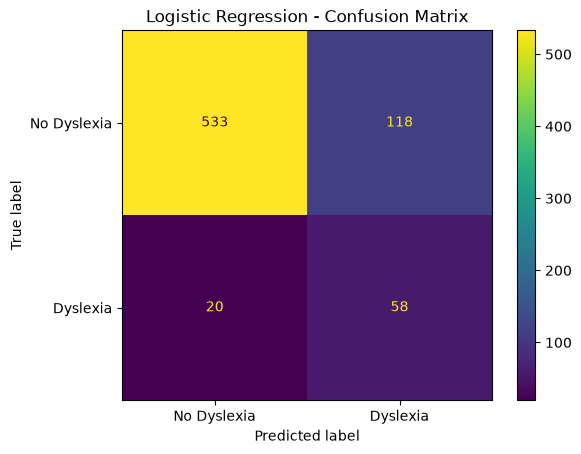

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=["No Dyslexia", "Dyslexia"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [40]:
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

In [41]:
logistic_auc = roc_auc_score(y_test, y_prob_logistic)

print("ROC-AUC:", logistic_auc)

ROC-AUC: 0.8411122927251959


## Random Forest

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [44]:

random_forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [45]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [47]:
print("Random Forest Results")
print("---------------------")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Results
---------------------
Accuracy: 0.9135802469135802
Precision: 0.7419354838709677
Recall: 0.2948717948717949
F1 Score: 0.42201834862385323
ROC-AUC: 0.8652664539761314


In [48]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Dyslexia", "Dyslexia"]
    
))

              precision    recall  f1-score   support

 No Dyslexia       0.92      0.99      0.95       651
    Dyslexia       0.74      0.29      0.42        78

    accuracy                           0.91       729
   macro avg       0.83      0.64      0.69       729
weighted avg       0.90      0.91      0.90       729



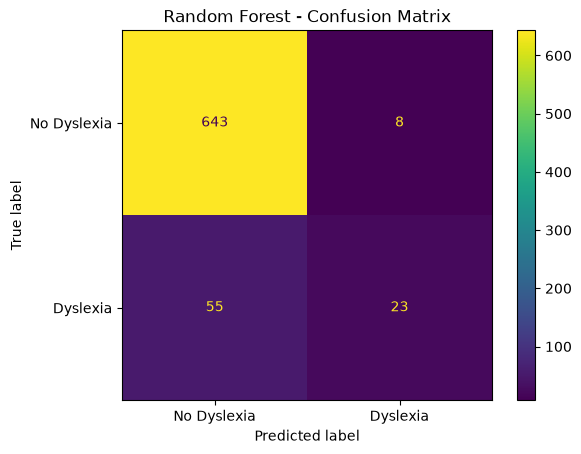

In [49]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["No Dyslexia", "Dyslexia"]
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

## Model Comparison

In [50]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf)
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf)
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.81070,0.329545,0.743590,0.456693,0.841112
1,Random Forest,0.91358,0.741935,0.294872,0.422018,0.865266


In [51]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf)
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf)
    ],
    
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf)
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.81070,0.329545,0.743590,0.456693,0.841112
1,Random Forest,0.91358,0.741935,0.294872,0.422018,0.865266


In [53]:
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training:", X_train2.shape)
print("Validation:", X_val.shape)

Training: (2332, 196)
Validation: (583, 196)


In [54]:
logistic_tuned = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

logistic_tuned.fit(X_train2, y_train2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](196,)","['Gender','Nativelang','Otherlang',...,'Score32','Accuracy32','Missrate32']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,196
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [55]:
logistic_tuned = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

logistic_tuned.fit(X_train2, y_train2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](196,)","['Gender','Nativelang','Otherlang',...,'Score32','Accuracy32','Missrate32']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,196
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [56]:
y_val_prob = logistic_tuned.predict_proba(X_val)[:, 1]

y_val_prob[:10]

array([8.81079903e-01, 1.46315138e-05, 7.95114042e-01, 9.29324152e-01,
       5.87534386e-01, 1.88001117e-02, 9.35075718e-01, 8.41843890e-01,
       3.71976911e-02, 5.73308367e-02])

In [57]:
thresholds = np.arange(0.1, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    
    predictions = (y_val_prob >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, predictions, zero_division=0),
        "Recall": recall_score(y_val, predictions),
        "F1": f1_score(y_val, predictions)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.174917,0.841270,0.289617
1,0.15,0.192029,0.841270,0.312684
2,0.20,0.212245,0.825397,0.337662
3,0.25,0.224215,0.793651,0.349650
4,0.30,0.234146,0.761905,0.358209
5,0.35,0.256983,0.730159,0.380165
6,0.40,0.275000,0.698413,0.394619
7,0.45,0.297297,0.698413,0.417062
8,0.50,0.309859,0.698413,0.429268
9,0.55,0.335938,0.682540,0.450262


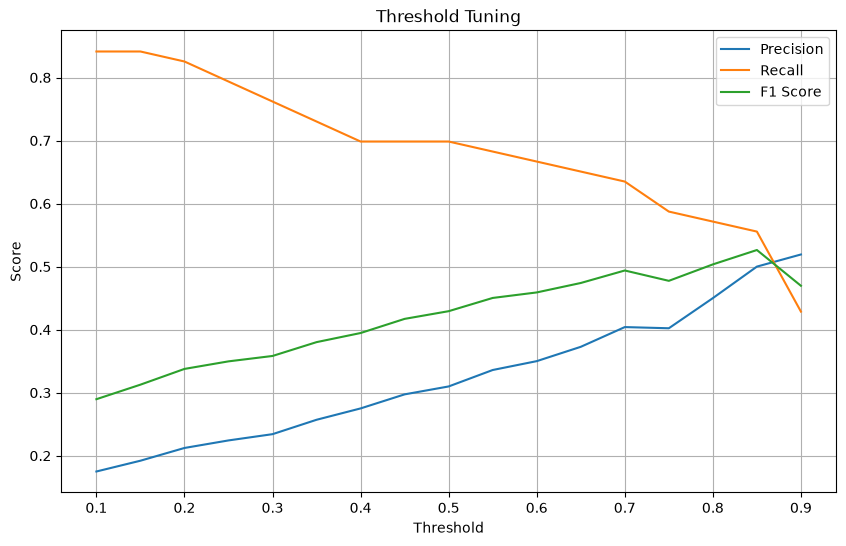

In [58]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.grid()

plt.show()

In [59]:
good_thresholds = threshold_df[
    threshold_df["Recall"] >= 0.80
]

good_thresholds

,Threshold,Precision,Recall,F1
0,0.10,0.174917,0.841270,0.289617
1,0.15,0.192029,0.841270,0.312684
2,0.20,0.212245,0.825397,0.337662


In [60]:
best_row = good_thresholds.loc[
    good_thresholds["F1"].idxmax()
]


best_row

Threshold    0.200000
Precision    0.212245
Recall       0.825397
F1           0.337662
Name: 2, dtype: float64

In [61]:
best_threshold = best_row["Threshold"]


print("Best threshold:", best_threshold)

Best threshold: 0.20000000000000004


In [62]:
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](196,)","['Gender','Nativelang','Otherlang',...,'Score32','Accuracy32','Missrate32']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,196
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [63]:
y_test_prob_final = final_model.predict_proba(X_test)[:, 1]

In [64]:
y_test_pred_final = (
    y_test_prob_final >= best_threshold
).astype(int)

In [65]:
print("FINAL MODEL")
print("-------------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_test_pred_final)
)

print(
    "Precision:",
    precision_score(y_test, y_test_pred_final)
)

print(
    "Recall:",
    recall_score(y_test, y_test_pred_final)
)

print(
    "F1 Score:",
    f1_score(y_test, y_test_pred_final)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_test_prob_final)
)

FINAL MODEL
-------------------------
Accuracy: 0.6419753086419753
Precision: 0.2113564668769716
Recall: 0.8589743589743589
F1 Score: 0.3392405063291139
ROC-AUC: 0.8411122927251959


In [66]:
print(
    classification_report(
        y_test,
        y_test_pred_final,
        target_names=[
            "No Dyslexia",
            "Dyslexia"
        ]
    )
)

              precision    recall  f1-score   support

 No Dyslexia       0.97      0.62      0.75       651
    Dyslexia       0.21      0.86      0.34        78

    accuracy                           0.64       729
   macro avg       0.59      0.74      0.55       729
weighted avg       0.89      0.64      0.71       729



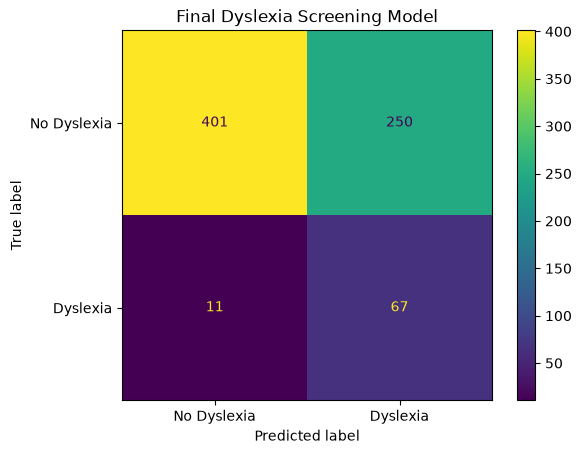

In [67]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_final,
    display_labels=[
        "No Dyslexia",
        "Dyslexia"
    ]
)

plt.title("Final Dyslexia Screening Model")
plt.show()

In [68]:
coefficients = final_model.named_steps[
    "model"
].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients,
    "Importance": np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Coefficient,Importance
11,Hits2,1.735562,1.735562
3,Age,1.324347,1.324347
166,Clicks28,-1.324143,1.324143
167,Hits28,-1.241532,1.241532
168,Misses28,1.157167,1.157167
169,Score28,0.974957,0.974957
13,Score2,-0.919736,0.919736
43,Score7,-0.796057,0.796057
1,Nativelang,0.788749,0.788749
61,Score10,-0.757410,0.757410


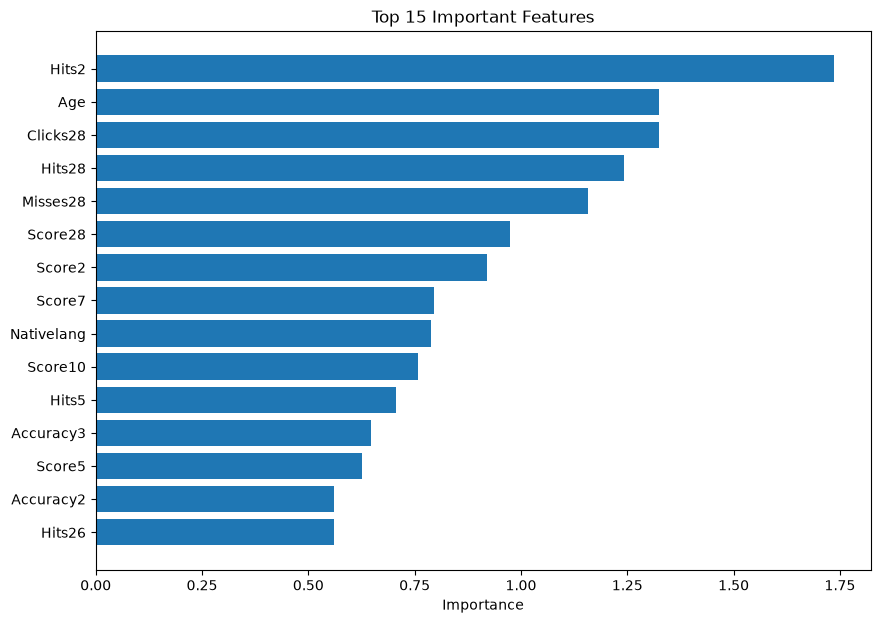

In [69]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [70]:
import joblib

In [71]:
joblib.dump(
    final_model,
    "dyslexia_model.pkl"
)

['dyslexia_model.pkl']

In [72]:
joblib.dump(
    best_threshold,
    "dyslexia_threshold.pkl"
)

['dyslexia_threshold.pkl']

In [73]:
joblib.dump(
    X.columns.tolist(),
    "dyslexia_features.pkl"
)

['dyslexia_features.pkl']

In [74]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [75]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }
)

In [76]:
print("Cross Validation Results")
print("------------------------")

print("Accuracy:", cv_scores["test_accuracy"].mean())
print("Precision:", cv_scores["test_precision"].mean())
print("Recall:", cv_scores["test_recall"].mean())
print("F1:", cv_scores["test_f1"].mean())
print("ROC-AUC:", cv_scores["test_roc_auc"].mean())

Cross Validation Results
------------------------
Accuracy: 0.8065180102915951
Precision: 0.31967778818302583
Recall: 0.6973886328725039
F1: 0.4378326127695901
ROC-AUC: 0.8327537894242744


In [77]:
cv_results = pd.DataFrame({
    "Accuracy": cv_scores["test_accuracy"],
    "Precision": cv_scores["test_precision"],
    "Recall": cv_scores["test_recall"],
    "F1": cv_scores["test_f1"],
    "ROC-AUC": cv_scores["test_roc_auc"]
})

cv_results

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.783877,0.283784,0.677419,0.400000,0.847316
1,0.826758,0.341667,0.650794,0.448087,0.840873
2,0.813036,0.333333,0.730159,0.457711,0.869292
3,0.816467,0.338235,0.730159,0.462312,0.803327
4,0.792453,0.301370,0.698413,0.421053,0.802961


In [78]:
cv_results.mean()

Accuracy     0.806518
Precision    0.319678
Recall       0.697389
F1           0.437833
ROC-AUC      0.832754
dtype: float64

In [79]:
cv_results.std()

Accuracy     0.017759
Precision    0.025680
Recall       0.034346
F1           0.026516
ROC-AUC      0.029011
dtype: float64

In [80]:
loaded_model = joblib.load("dyslexia_model.pkl")
loaded_threshold = joblib.load("dyslexia_threshold.pkl")
loaded_features = joblib.load("dyslexia_features.pkl")

In [81]:
print("Threshold:", loaded_threshold)
print("Number of features:", len(loaded_features))

Threshold: 0.20000000000000004
Number of features: 196


In [82]:
def predict_dyslexia_screening(input_data):
    
    input_df = pd.DataFrame([input_data])

    # ترتيب الأعمدة بنفس ترتيب التدريب
    input_df = input_df[loaded_features]

    score = loaded_model.predict_proba(input_df)[0, 1]

    prediction = int(score >= loaded_threshold)

    if prediction == 1:
        result = "Further screening recommended"
    else:
        result = "No screening flag"

    return {
        "screening_score": float(score),
        "prediction": prediction,
        "result": result
    }

In [83]:
sample_child = X_test.iloc[0].to_dict()

sample_result = predict_dyslexia_screening(sample_child)

sample_result

{'screening_score': 0.029362776150552564,
 'prediction': 0,
 'result': 'No screening flag'}

In [84]:
sample_index = X_test.index[0]

print("Model result:")
print(sample_result)

print("\nActual label:")
print(y_test.loc[sample_index])

Model result:
{'screening_score': 0.029362776150552564, 'prediction': 0, 'result': 'No screening flag'}

Actual label:
0


In [85]:
from sklearn.base import clone

cv_threshold_results = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), start=1):

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # نسخة جديدة من الموديل لكل fold
    model = clone(logistic_model)

    model.fit(X_fold_train, y_fold_train)

    # probabilities
    probabilities = model.predict_proba(X_fold_val)[:, 1]

    # نستخدم threshold = 0.20
    predictions = (
        probabilities >= best_threshold
    ).astype(int)

    cv_threshold_results.append({
        "Fold": fold,
        "Accuracy": accuracy_score(y_fold_val, predictions),
        "Precision": precision_score(
            y_fold_val,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(y_fold_val, predictions),
        "F1": f1_score(y_fold_val, predictions),
        "ROC-AUC": roc_auc_score(
            y_fold_val,
            probabilities
        )
    })

In [86]:
cv_threshold_df = pd.DataFrame(cv_threshold_results)

cv_threshold_df

,Fold,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,0.658662,0.222672,0.887097,0.355987,0.847316
1,2,0.679245,0.230435,0.841270,0.361775,0.840873
2,3,0.680961,0.240506,0.904762,0.380000,0.869292
3,4,0.686106,0.229730,0.809524,0.357895,0.803327
4,5,0.632933,0.199203,0.793651,0.318471,0.802961


In [87]:
cv_threshold_df.mean(numeric_only=True)

Fold         3.000000
Accuracy     0.667581
Precision    0.224509
Recall       0.847261
F1           0.354826
ROC-AUC      0.832754
dtype: float64

In [88]:
cv_threshold_df.std(numeric_only=True)

Fold         1.581139
Accuracy     0.022013
Precision    0.015508
Recall       0.048029
F1           0.022441
ROC-AUC      0.029011
dtype: float64

In [89]:
test_results = []

for i in range(20):

    child = X_test.iloc[i].to_dict()

    result = predict_dyslexia_screening(child)

    actual = y_test.iloc[i]

    test_results.append({
        "Child": i + 1,
        "Score": result["screening_score"],
        "Prediction": result["prediction"],
        "Actual": actual,
        "Correct": result["prediction"] == actual
    })

test_samples_df = pd.DataFrame(test_results)

test_samples_df

,Child,Score,Prediction,Actual,Correct
0,1,2.936278e-02,0,0,True
1,2,4.340907e-03,0,0,True
2,3,2.583355e-01,1,0,False
3,4,3.711709e-01,1,0,False
4,5,6.370279e-01,1,1,True
5,6,1.317188e-01,0,0,True
6,7,1.119334e-01,0,0,True
7,8,8.499947e-07,0,0,True
8,9,6.828842e-02,0,0,True
9,10,4.265116e-01,1,0,False


In [90]:
test_samples_df["Prediction Label"] = test_samples_df[
    "Prediction"
].map({
    0: "No Flag",
    1: "Further Screening"
})

test_samples_df["Actual Label"] = test_samples_df[
    "Actual"
].map({
    0: "No Dyslexia",
    1: "Dyslexia"
})

test_samples_df[
    [
        "Child",
        "Score",
        "Prediction Label",
        "Actual Label",
        "Correct"
    ]
]

,Child,Score,Prediction Label,Actual Label,Correct
0,1,2.936278e-02,No Flag,No Dyslexia,True
1,2,4.340907e-03,No Flag,No Dyslexia,True
2,3,2.583355e-01,Further Screening,No Dyslexia,False
3,4,3.711709e-01,Further Screening,No Dyslexia,False
4,5,6.370279e-01,Further Screening,Dyslexia,True
5,6,1.317188e-01,No Flag,No Dyslexia,True
6,7,1.119334e-01,No Flag,No Dyslexia,True
7,8,8.499947e-07,No Flag,No Dyslexia,True
8,9,6.828842e-02,No Flag,No Dyslexia,True
9,10,4.265116e-01,Further Screening,No Dyslexia,False


In [91]:
accuracy_columns = [
    col for col in df.columns
    if col.startswith("Accuracy")
]

accuracy_stats = df[
    accuracy_columns
].describe().T

accuracy_stats

,count,mean,std,min,25%,50%,75%,max
Accuracy1,3644.0,3.047372,35.446814,0.0,0.000000,0.500000,1.000000,875.0
Accuracy2,3644.0,5.031541,53.535001,0.0,0.200000,0.500000,1.000000,875.0
Accuracy3,3644.0,4.345743,44.548640,0.0,0.111111,0.690000,1.000000,875.0
Accuracy4,3644.0,20.625074,113.941291,0.0,0.500000,0.800000,1.000000,875.0
Accuracy5,3644.0,11.000004,89.795213,0.0,0.666667,1.000000,1.000000,875.0
Accuracy6,3644.0,12.988314,99.662610,0.0,0.600000,1.000000,1.000000,875.0
Accuracy7,3644.0,23.215121,136.175070,0.0,0.800000,1.000000,1.000000,875.0
Accuracy8,3644.0,13.786396,101.093863,0.0,0.750000,1.000000,1.000000,875.0
Accuracy9,3644.0,6.903907,69.926561,0.0,0.622500,1.000000,1.000000,875.0
Accuracy10,3644.0,11.374634,93.057288,0.0,1.000000,1.000000,1.000000,875.0


In [92]:
accuracy_stats[
    ["min", "mean", "50%", "max"]
]

,min,mean,50%,max
Accuracy1,0.0,3.047372,0.500000,875.0
Accuracy2,0.0,5.031541,0.500000,875.0
Accuracy3,0.0,4.345743,0.690000,875.0
Accuracy4,0.0,20.625074,0.800000,875.0
Accuracy5,0.0,11.000004,1.000000,875.0
Accuracy6,0.0,12.988314,1.000000,875.0
Accuracy7,0.0,23.215121,1.000000,875.0
Accuracy8,0.0,13.786396,1.000000,875.0
Accuracy9,0.0,6.903907,1.000000,875.0
Accuracy10,0.0,11.374634,1.000000,875.0


In [93]:
for col in accuracy_columns:

    count = (df[col] > 1).sum()

    if count > 0:
        print(
            col,
            "values > 1:",
            count,
            "max:",
            df[col].max()
        )

Accuracy1 values > 1: 39 max: 875.0
Accuracy2 values > 1: 50 max: 875.0
Accuracy3 values > 1: 59 max: 875.0
Accuracy4 values > 1: 126 max: 875.0
Accuracy5 values > 1: 52 max: 875.0
Accuracy6 values > 1: 59 max: 875.0
Accuracy7 values > 1: 97 max: 875.0
Accuracy8 values > 1: 66 max: 875.0
Accuracy9 values > 1: 31 max: 875.0
Accuracy10 values > 1: 49 max: 875.0
Accuracy11 values > 1: 32 max: 875.0
Accuracy12 values > 1: 18 max: 875.0
Accuracy13 values > 1: 7 max: 875.0
Accuracy14 values > 1: 40 max: 875.0
Accuracy15 values > 1: 18 max: 875.0
Accuracy16 values > 1: 39 max: 875.0
Accuracy17 values > 1: 21 max: 875.0
Accuracy18 values > 1: 35 max: 875.0
Accuracy19 values > 1: 101 max: 875.0
Accuracy20 values > 1: 69 max: 875.0
Accuracy21 values > 1: 32 max: 625.0
Accuracy22 values > 1: 106 max: 875.0
Accuracy23 values > 1: 104 max: 875.0
Accuracy24 values > 1: 51 max: 875.0
Accuracy25 values > 1: 113 max: 875.0
Accuracy26 values > 1: 142 max: 875.0
Accuracy27 values > 1: 62 max: 625.0
Accur

In [94]:
missrate_columns = [
    col for col in df.columns
    if col.startswith("Missrate")
]

for col in missrate_columns:

    count = (df[col] > 1).sum()

    if count > 0:
        print(
            col,
            "values > 1:",
            count,
            "max:",
            df[col].max()
        )

Missrate1 values > 1: 48 max: 625.0
Missrate2 values > 1: 77 max: 875.0
Missrate3 values > 1: 48 max: 875.0
Missrate4 values > 1: 126 max: 875.0
Missrate5 values > 1: 52 max: 875.0
Missrate6 values > 1: 59 max: 875.0
Missrate7 values > 1: 97 max: 625.0
Missrate8 values > 1: 66 max: 875.0
Missrate9 values > 1: 31 max: 875.0
Missrate10 values > 1: 49 max: 875.0
Missrate11 values > 1: 32 max: 875.0
Missrate12 values > 1: 18 max: 875.0
Missrate13 values > 1: 7 max: 975.0
Missrate14 values > 1: 40 max: 875.0
Missrate15 values > 1: 18 max: 875.0
Missrate16 values > 1: 39 max: 875.0
Missrate17 values > 1: 21 max: 875.0
Missrate18 values > 1: 35 max: 975.0
Missrate19 values > 1: 101 max: 875.0
Missrate20 values > 1: 69 max: 875.0
Missrate21 values > 1: 32 max: 875.0
Missrate22 values > 1: 106 max: 875.0
Missrate23 values > 1: 104 max: 875.0
Missrate24 values > 1: 51 max: 875.0
Missrate25 values > 1: 113 max: 875.0
Missrate26 values > 1: 142 max: 875.0
Missrate27 values > 1: 76 max: 875.0
Missr

## # Clean Model V2

In [95]:
clean_df = data.copy()

In [96]:
clean_df["Dyslexia"] = clean_df["Dyslexia"].map({
    "No": 0,
    "Yes": 1
})

clean_df["Gender"] = clean_df["Gender"].map({
    "Male": 0,
    "Female": 1
})

clean_df["Nativelang"] = clean_df["Nativelang"].map({
    "No": 0,
    "Yes": 1
})

clean_df["Otherlang"] = clean_df["Otherlang"].map({
    "No": 0,
    "Yes": 1
})

In [97]:
for i in range(1, 33):

    clicks = clean_df[f"Clicks{i}"].astype(float)
    hits = clean_df[f"Hits{i}"].astype(float)
    misses = clean_df[f"Misses{i}"].astype(float)

    clean_df[f"Accuracy{i}"] = np.where(
        clicks > 0,
        hits / clicks,
        0.0
    )

    clean_df[f"Missrate{i}"] = np.where(
        clicks > 0,
        misses / clicks,
        0.0
    )

In [98]:
accuracy_columns = [
    f"Accuracy{i}"
    for i in range(1, 33)
]

missrate_columns = [
    f"Missrate{i}"
    for i in range(1, 33)
]

In [99]:
print(
    "Maximum Accuracy:",
    clean_df[accuracy_columns].max().max()
)

print(
    "Maximum Missrate:",
    clean_df[missrate_columns].max().max()
)

print(
    "Minimum Accuracy:",
    clean_df[accuracy_columns].min().min()
)

print(
    "Minimum Missrate:",
    clean_df[missrate_columns].min().min()
)

Maximum Accuracy: 1.0
Maximum Missrate: 1.0
Minimum Accuracy: 0.0
Minimum Missrate: 0.0


In [100]:
print(
    "Accuracy > 1:",
    (clean_df[accuracy_columns] > 1).sum().sum()
)

print(
    "Missrate > 1:",
    (clean_df[missrate_columns] > 1).sum().sum()
)

Accuracy > 1: 0
Missrate > 1: 0


In [101]:
X_clean = clean_df.drop(
    "Dyslexia",
    axis=1
)

y_clean = clean_df["Dyslexia"]

In [102]:
print(X_clean.shape)
print(y_clean.shape)

(3644, 196)
(3644,)


In [103]:
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.20,
    random_state=42,
    stratify=y_clean
)

In [104]:
print("Train:", X_train_clean.shape)
print("Test:", X_test_clean.shape)

print()
print(y_train_clean.value_counts(normalize=True))
print(y_test_clean.value_counts(normalize=True))

Train: (2915, 196)
Test: (729, 196)

Dyslexia
0    0.892281
1    0.107719
Name: proportion, dtype: float64
Dyslexia
0    0.893004
1    0.106996
Name: proportion, dtype: float64


In [105]:
logistic_clean = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

In [106]:
logistic_clean.fit(
    X_train_clean,
    y_train_clean
    
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](196,)","['Gender','Nativelang','Otherlang',...,'Score32','Accuracy32','Missrate32']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,196
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [107]:
y_pred_clean = logistic_clean.predict(
    X_test_clean
)

y_prob_clean = logistic_clean.predict_proba(
    X_test_clean
)[:, 1]

In [108]:
print("CLEAN MODEL - threshold 0.50")
print("----------------------------")

print(
    "Accuracy:",
    accuracy_score(
        y_test_clean,
        y_pred_clean
    )
)

print(
    "Precision:",
    precision_score(
        y_test_clean,
        y_pred_clean
    )
)

print(
    "Recall:",
    recall_score(
        y_test_clean,
        y_pred_clean
    )
)

print(
    "F1:",
    f1_score(
        y_test_clean,
        y_pred_clean
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test_clean,
        y_prob_clean
    )
)

CLEAN MODEL - threshold 0.50
----------------------------
Accuracy: 0.8010973936899863
Precision: 0.3149171270718232
Recall: 0.7307692307692307
F1: 0.44015444015444016
ROC-AUC: 0.8619087006183781


In [109]:
X_train2_clean, X_val_clean, y_train2_clean, y_val_clean = train_test_split(
    X_train_clean,
    y_train_clean,
    test_size=0.20,
    random_state=42,
    stratify=y_train_clean
)

In [110]:
threshold_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

threshold_model.fit(
    X_train2_clean,
    y_train2_clean
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](196,)","['Gender','Nativelang','Otherlang',...,'Score32','Accuracy32','Missrate32']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,196
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [111]:
val_prob_clean = threshold_model.predict_proba(
    X_val_clean
)[:, 1]

In [112]:
thresholds = np.arange(
    0.05,
    0.51,
    0.01
)

threshold_results_clean = []

for threshold in thresholds:

    predictions = (
        val_prob_clean >= threshold
    ).astype(int)

    threshold_results_clean.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val_clean,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val_clean,
            predictions
        ),
        "F1": f1_score(
            y_val_clean,
            predictions
        )
    })

threshold_clean_df = pd.DataFrame(
    threshold_results_clean
)

threshold_clean_df

,Threshold,Precision,Recall,F1
0,0.05,0.162011,0.920635,0.275534
1,0.06,0.169096,0.920635,0.285714
2,0.07,0.174312,0.904762,0.292308
3,0.08,0.180380,0.904762,0.300792
4,0.09,0.184466,0.904762,0.306452
5,0.10,0.184211,0.888889,0.305177
6,0.11,0.188552,0.888889,0.311111
7,0.12,0.189831,0.888889,0.312849
8,0.13,0.197880,0.888889,0.323699
9,0.14,0.202206,0.873016,0.328358


In [113]:
candidate_thresholds = threshold_clean_df[
    threshold_clean_df["Recall"] >= 0.80
]

In [114]:
candidate_thresholds.sort_values(
    "F1",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1
23,0.28,0.247573,0.809524,0.379182
22,0.27,0.244019,0.809524,0.375000
21,0.26,0.241706,0.809524,0.372263
18,0.23,0.238739,0.841270,0.371930
20,0.25,0.240566,0.809524,0.370909
17,0.22,0.233766,0.857143,0.367347
19,0.24,0.236111,0.809524,0.365591
16,0.21,0.231760,0.857143,0.364865
15,0.20,0.225941,0.857143,0.357616
14,0.19,0.222222,0.857143,0.352941


In [115]:
best_clean_row = candidate_thresholds.loc[
    candidate_thresholds["F1"].idxmax()
]

best_clean_row

Threshold    0.280000
Precision    0.247573
Recall       0.809524
F1           0.379182
Name: 23, dtype: float64

In [116]:
best_clean_threshold = best_clean_row[
    "Threshold"
]

print(
    "Best clean threshold:",
    best_clean_threshold

)

Best clean threshold: 0.28


In [117]:
final_clean_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        )
    )
])

final_clean_model.fit(
    X_train_clean,
    y_train_clean
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](196,)","['Gender','Nativelang','Otherlang',...,'Score32','Accuracy32','Missrate32']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,196
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [118]:
final_clean_prob = final_clean_model.predict_proba(
    X_test_clean
)[:, 1]

final_clean_pred = (
    final_clean_prob >= best_clean_threshold
).astype(int)

In [119]:
print("FINAL CLEAN MODEL")
print("=================")

print(
    "Accuracy:",
    accuracy_score(
        y_test_clean,
        final_clean_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_test_clean,
        final_clean_pred
    )
)

print(
    "Recall:",
    recall_score(
        y_test_clean,
        final_clean_pred
    )
)

print(
    "F1:",
    f1_score(
        y_test_clean,
        final_clean_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test_clean,
        final_clean_prob
    )
)

FINAL CLEAN MODEL
Accuracy: 0.7064471879286695
Precision: 0.2462686567164179
Recall: 0.8461538461538461
F1: 0.3815028901734104
ROC-AUC: 0.8619087006183781


In [120]:
print(
    classification_report(
        y_test_clean,
        final_clean_pred,
        target_names=[
            "No Dyslexia",
            "Dyslexia"
        ]
    )
    
)

              precision    recall  f1-score   support

 No Dyslexia       0.97      0.69      0.81       651
    Dyslexia       0.25      0.85      0.38        78

    accuracy                           0.71       729
   macro avg       0.61      0.77      0.59       729
weighted avg       0.90      0.71      0.76       729



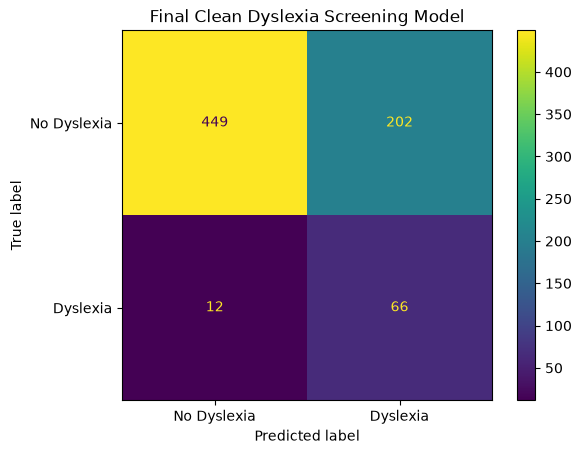

In [121]:
ConfusionMatrixDisplay.from_predictions(
    y_test_clean,
    final_clean_pred,
    display_labels=[
        "No Dyslexia",
        "Dyslexia"
    ]
)

plt.title(
    "Final Clean Dyslexia Screening Model"
)

plt.show()

In [122]:
print("FINAL CLEAN MODEL")

FINAL CLEAN MODEL


## Clean Model Cross Validation

In [123]:
from sklearn.base import clone

clean_cv_results = []

clean_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_idx, val_idx) in enumerate(
    clean_cv.split(X_train_clean, y_train_clean),
    start=1
):

    X_fold_train = X_train_clean.iloc[train_idx]
    X_fold_val = X_train_clean.iloc[val_idx]

    y_fold_train = y_train_clean.iloc[train_idx]
    y_fold_val = y_train_clean.iloc[val_idx]

    model = clone(final_clean_model)

    model.fit(
        X_fold_train,
        y_fold_train
    )

    probabilities = model.predict_proba(
        X_fold_val
    )[:, 1]

    predictions = (
        probabilities >= best_clean_threshold
    ).astype(int)

    clean_cv_results.append({
        "Fold": fold,

        "Accuracy": accuracy_score(
            y_fold_val,
            predictions
        ),

        "Precision": precision_score(
            y_fold_val,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_fold_val,
            predictions
        ),

        "F1": f1_score(
            y_fold_val,
            predictions
        ),

        "ROC-AUC": roc_auc_score(
            y_fold_val,
            probabilities
        )
    })

In [124]:
clean_cv_df = pd.DataFrame(clean_cv_results)

clean_cv_df

,Fold,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,0.727273,0.253807,0.806452,0.386100,0.845428
1,2,0.720412,0.257282,0.841270,0.394052,0.850946
2,3,0.732419,0.273171,0.888889,0.417910,0.877320
3,4,0.735849,0.264249,0.809524,0.398438,0.820391
4,5,0.710120,0.252336,0.857143,0.389892,0.866270


In [125]:
print("MEAN")
print(clean_cv_df.mean(numeric_only=True))

print("\nSTD")
print(clean_cv_df.std(numeric_only=True))

MEAN
Fold         3.000000
Accuracy     0.725214
Precision    0.260169
Recall       0.840655
F1           0.397278
ROC-AUC      0.852071
dtype: float64

STD
Fold         1.581139
Accuracy     0.010249
Precision    0.008600
Recall       0.034416
F1           0.012419
ROC-AUC      0.021726
dtype: float64


## Feature Importance

In [126]:
coefficients = final_clean_model.named_steps[
    "model"
].coef_[0]

feature_importance_clean = pd.DataFrame({
    "Feature": X_clean.columns,
    "Coefficient": coefficients,
    "Importance": np.abs(coefficients)
})

feature_importance_clean = (
    feature_importance_clean
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance_clean.head(20)

,Feature,Coefficient,Importance
11,Hits2,1.506384,1.506384
3,Age,1.331272,1.331272
168,Misses28,1.217222,1.217222
167,Hits28,-1.206329,1.206329
43,Score7,-1.099821,1.099821
166,Clicks28,-1.052113,1.052113
20,Accuracy3,-0.898144,0.898144
12,Misses2,0.824803,0.824803
188,Accuracy31,-0.820588,0.820588
1,Nativelang,0.817358,0.817358


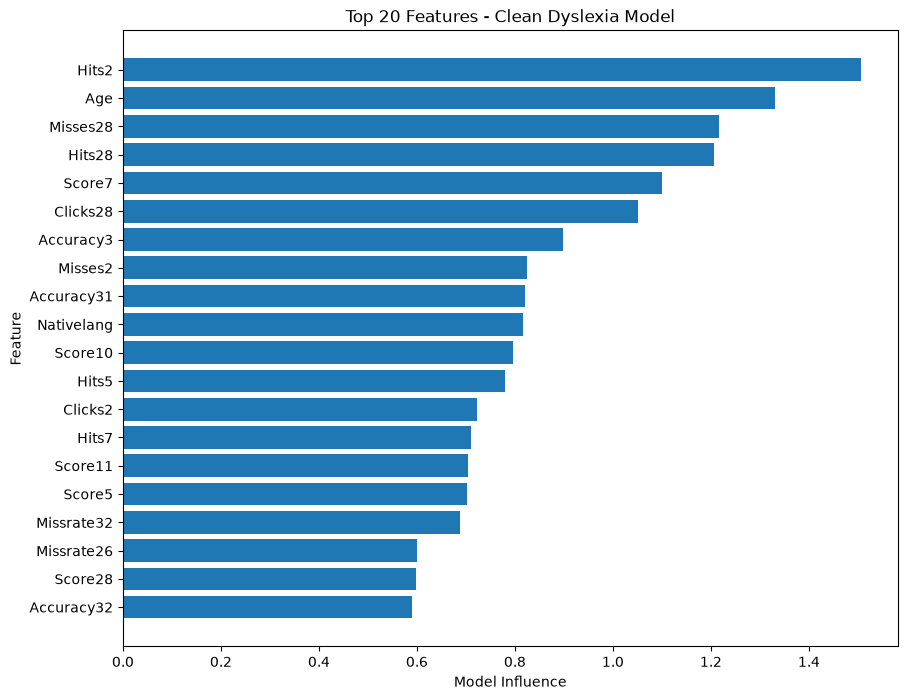

In [127]:
top_20 = feature_importance_clean.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_20["Feature"],
    top_20["Importance"]
)

plt.xlabel("Model Influence")
plt.ylabel("Feature")
plt.title("Top 20 Features - Clean Dyslexia Model")

plt.gca().invert_yaxis()

plt.show()

In [128]:
import joblib

joblib.dump(
    final_clean_model,
    "dyslexia_model_v2.pkl"
)

joblib.dump(
    best_clean_threshold,
    "dyslexia_threshold_v2.pkl"
)

joblib.dump(
    X_clean.columns.tolist(),
    "dyslexia_features_v2.pkl"
)

['dyslexia_features_v2.pkl']

In [129]:
loaded_model_v2 = joblib.load(
    "dyslexia_model_v2.pkl"
)

loaded_threshold_v2 = joblib.load(
    "dyslexia_threshold_v2.pkl"
)

loaded_features_v2 = joblib.load(
    "dyslexia_features_v2.pkl"
)

In [130]:
def prepare_child_data(raw_data):

    child = raw_data.copy()

    # Convert categorical data if text is provided
    if isinstance(child["Gender"], str):
        child["Gender"] = {
            "Male": 0,
            "Female": 1
        }[child["Gender"]]

    if isinstance(child["Nativelang"], str):
        child["Nativelang"] = {
            "No": 0,
            "Yes": 1
        }[child["Nativelang"]]

    if isinstance(child["Otherlang"], str):
        child["Otherlang"] = {
            "No": 0,
            "Yes": 1
        }[child["Otherlang"]]

    # Calculate derived features
    for i in range(1, 33):

        clicks = float(
            child[f"Clicks{i}"]
        )

        hits = float(
            child[f"Hits{i}"]
        )

        misses = float(
            child[f"Misses{i}"]
        )

        if clicks > 0:

            child[f"Accuracy{i}"] = (
                hits / clicks
            )

            child[f"Missrate{i}"] = (
                misses / clicks
            )

        else:

            child[f"Accuracy{i}"] = 0.0
            child[f"Missrate{i}"] = 0.0

    input_df = pd.DataFrame(
        [child]
    )

    input_df = input_df[
        loaded_features_v2
    ]

    return input_df

In [131]:
def predict_child(raw_data):

    input_df = prepare_child_data(
        raw_data
    )

    screening_score = (
        loaded_model_v2
        .predict_proba(input_df)[0, 1]
    )

    flag = int(
        screening_score >= loaded_threshold_v2
    )

    if flag == 1:

        result = (
            "Further screening recommended"
        )

    else:

        result = "No screening flag"

    return {
        "screening_score": float(
            screening_score
        ),

        "screening_flag": flag,

        "result": result
    }

In [132]:
sample = X_test_clean.iloc[0].to_dict()

for i in range(1, 33):

    sample.pop(
        f"Accuracy{i}",
        None
    )

    sample.pop(
        f"Missrate{i}",
        None
        
    )

In [133]:
result = predict_child(sample)

result

{'screening_score': 0.013683327489167585,
 'screening_flag': 0,
 'result': 'No screening flag'}

In [134]:
print("Prediction:")
print(result)

print()

print("Actual:")
print(y_test_clean.iloc[0])

Prediction:
{'screening_score': 0.013683327489167585, 'screening_flag': 0, 'result': 'No screening flag'}

Actual:
0


In [136]:
import json

# Get scaler and logistic regression from the trained pipeline
scaler = final_clean_model.named_steps["scaler"]
model = final_clean_model.named_steps["model"]

flutter_model = {
    "feature_names": X_clean.columns.tolist(),
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "coefficients": model.coef_[0].tolist(),
    "intercept": float(model.intercept_[0]),
    "threshold": float(best_clean_threshold)
}

with open(
    "dyslexia_flutter_model.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        flutter_model,
        file,
        indent=2
    )

print("Flutter model exported successfully.")
print("Number of features:", len(flutter_model["feature_names"]))
print("Threshold:", flutter_model["threshold"])

Flutter model exported successfully.
Number of features: 196
Threshold: 0.28
